# Experiment 5: Diffusion with Reversible Binding Kinetics
**Drug Modeled:** Lidocaine  
**Condition Tested:** Effect of reversible molecular binding on drug diffusion  
**Research Question:** How do reversible binding interactions between Lidocaine and tissue components affect free drug concentration and penetration depth?

## Background

In previous experiments, drug diffusion was modeled assuming that all molecules 
remain freely available to move through tissue. Experiment 5 initially improved 
this by introducing a first-order decay term to represent drug loss due to 
binding or uptake.

However, real biological binding is more complex and cannot be accurately 
described as simple decay. Molecular binding in tissue has three key properties:

**Concentration-dependent:** Binding rate depends on how much free drug is present  
**Reversible:** Bound drug can detach and return to the free pool  
**Saturable:** There is a limited number of available binding sites  

To capture these dynamics, this experiment models drug transport using a 
coupled system of differential equations:

∂C/∂t = D ∂²C/∂x² − k_on · C · B + k_off · C_bound  
∂C_bound/∂t = k_on · C · B − k_off · C_bound  

Where:

- C = free drug concentration (able to diffuse)
- C_bound = drug bound to tissue (immobile)
- B = available binding sites
- k_on = binding rate constant
- k_off = unbinding rate constant

In this model:

- Free drug diffuses through tissue
- Some fraction binds to tissue (removing it from diffusion)
- Bound drug can later unbind and re-enter the system

This creates a dynamic equilibrium between free and bound drug, rather than 
permanent loss.

All simulations use fixed diffusion parameters while varying binding strength 
to observe its effect on penetration depth.

Note: In this model, binding site concentration (B) is assumed constant. 
In reality, binding sites may become saturated, which would further affect 
drug dynamics.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('figures', exist_ok=True)

# ── Parameters ────────────────────────────────────────────────────────────────

# Diffusion coefficient (cm²/s)
D = 1.25e-8  

# Spatial domain (0 to 1.5 mm → 0.15 cm)
L = 0.15
nx = 200
dx = L / nx

x = np.linspace(0, L, nx)

# Time parameters
T = 600          # total time (10 minutes)
nt = 5000
dt = T / nt

# Binding kinetics
k_on = 1.0       # binding rate
k_off = 0.1      # unbinding rate
B = 1.0          # available binding sites (assumed constant)

# Initial concentrations
C = np.zeros(nx)          # free drug
C_bound = np.zeros(nx)    # bound drug

# Boundary condition (constant surface concentration)
C[0] = 20.0   # mg/mL

In [2]:
# ── Time Evolution ────────────────────────────────────────────────────────────

for n in range(nt):
    C_new = C.copy()
    Cb_new = C_bound.copy()
    
    for i in range(1, nx-1):
        # Diffusion term (same as before)
        diffusion = D * (C[i+1] - 2*C[i] + C[i-1]) / dx**2
        
        # Binding and unbinding
        bind = k_on * C[i] * B
        unbind = k_off * C_bound[i]
        
        # Update free drug
        C_new[i] = C[i] + dt * (diffusion - bind + unbind)
        
        # Update bound drug
        Cb_new[i] = C_bound[i] + dt * (bind - unbind)
    
    # Update arrays
    C = C_new
    C_bound = Cb_new
    
    # Re-apply boundary condition
    C[0] = 20.0

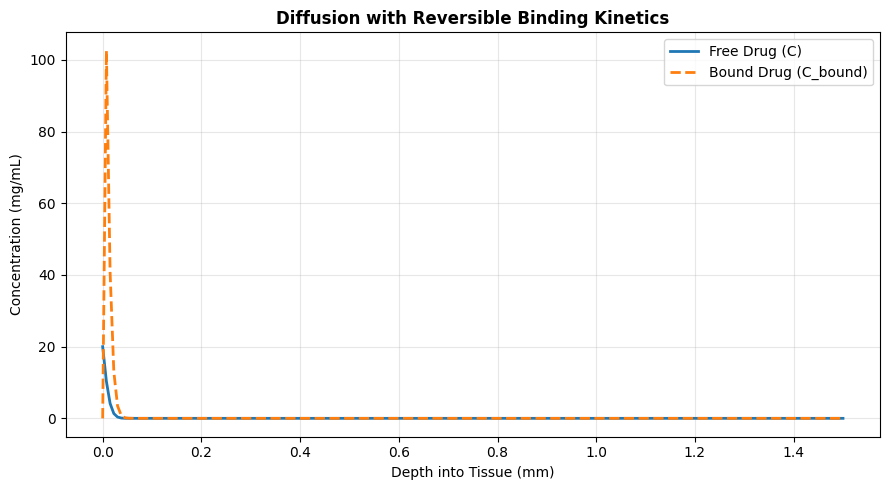

In [3]:
# ── Plot ──────────────────────────────────────────────────────────────────────

plt.figure(figsize=(9,5))

plt.plot(x * 10, C, label="Free Drug (C)", linewidth=2)
plt.plot(x * 10, C_bound, linestyle='--', label="Bound Drug (C_bound)", linewidth=2)

plt.title("Diffusion with Reversible Binding Kinetics", fontweight='bold')
plt.xlabel("Depth into Tissue (mm)")
plt.ylabel("Concentration (mg/mL)")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/exp05_binding_pde.png', dpi=150)
plt.show()

## Observations

- Free drug concentration decreases more gradually compared to the decay-only model
- Bound drug accumulates near the surface where concentration is highest
- Over time, some bound drug is released, sustaining free drug levels at deeper regions
- Higher binding rates increase initial drug loss but also increase delayed release effects
- The presence of reversible binding creates a more distributed and sustained concentration profile

## Interpretation

Reversible binding introduces a dynamic balance between free and bound drug, 
significantly altering transport behavior. Unlike irreversible decay, binding 
does not permanently remove drug from the system, but instead temporarily 
stores it within tissue.

This results in slower initial penetration but more sustained drug availability 
over time. In some cases, binding can act as a reservoir, allowing drug to 
gradually diffuse deeper even after initial administration.

Clinically, this suggests that drugs with moderate binding affinity may achieve 
more sustained therapeutic effects, while extremely high binding could still 
limit effective penetration. Accurate modeling of these interactions is essential 
for predicting real drug behavior in biological tissue.